In [31]:
#VaR tests and vizualization
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt

from Vares_simulations import *

from Vares import _terminal_returns, historical_var

Vares.ENABLE_TIMING = False

import pickle

#import the USD data 
with open('prices_usd.pkl', 'rb') as f: 
    prices_usd = pickle.load(f)

with open('original_returns_usd.pkl', 'rb') as f: 
    original_returns_usd = pickle.load(f)

with open('log_returns_usd.pkl', 'rb') as f: 
    log_returns_usd = pickle.load(f)    

original_returns_usd_scaled = original_returns_usd * 100
log_returns_usd_scaled = log_returns_usd * 100

from GARCH_VaR_delete_or_merge import fit_GARCH_VaR, normal_GARCH_simulation

In [45]:
def _GARCH_type_normal_simulation(vol_type: str, horizon=10, n_paths=50_000, alpha=0.01, **kwargs): 
    def simulate(returns):
        model = arch_model(returns, vol=vol_type, p=1, q=1, dist='normal', **kwargs)
        # results = model.fit(disp='off', options={'maxiter': 4000, 'eps': 1e-8})
        results = model.fit(disp='off')
        forecast = results.forecast(horizon=horizon, method='simulation')
        mu = results.params.get("mu", 0)
        sigma2 = forecast.variance.values[0]
        sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
        # nu = results.params.get('nu', 0)
        parameters = SimParams(volatility=sigma, mean=mu)

        # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
        sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

        # plt.hist(sim_returns, bins=50)
        # plt.show()

        VaR = historical_var(sim_returns, alpha)
        
        return VaR
    
    return simulate

In [46]:
FIGARCH_simulation = _GARCH_type_normal_simulation(vol_type='FIGARCH')
APARCH_simulation = _GARCH_type_normal_simulation(vol_type='APARCH', o=1)

In [ ]:
from arch.univariate import HARCH, MIDASHyperbolic

def HARCH_type_simulation(lags): 
    def simulate(returns, horizon=10, n_paths=50_000, alpha=0.01):
        model = arch_model(returns, vol='harch', p=lags, dist='normal')
        results = model.fit(disp='off')
        forecast = results.forecast(horizon=horizon)
        mu = results.params.get("mu", 0)
        sigma2 = forecast.variance.values[0]
        sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
        # nu = results.params.get('nu', 0)
        parameters = SimParams(volatility=sigma, mean=mu)

        # _ = solve_local_vol_gbm(parameters, 10, n_paths=n_paths)
        sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

        # plt.hist(sim_returns, bins=50)
        # plt.show()

        VaR = historical_var(sim_returns, alpha)
        
        return VaR

    return simulate



    

In [83]:
HARCH_1_5_22_simulation = HARCH_type_simulation([1, 5, 22])
HARCH_5_simulation = HARCH_type_simulation([5])

In [ ]:
figarch_vars = fit_GARCH_VaR(log_returns_usd, FIGARCH_simulation) 
_figarch_vars = np.multiply(figarch_vars, -1)
aparch_vars = fit_GARCH_VaR(log_returns_usd, APARCH_simulation)
_aparch_vars = np.multiply(aparch_vars, -1)
norm_vars = fit_GARCH_VaR(log_returns_usd, normal_GARCH_simulation) 
_norm_vars = np.multiply(norm_vars, -1)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
d:\Users\alexa\A

In [ ]:
harch_1_5_22_vars = fit_GARCH_VaR(log_returns_usd, HARCH_1_5_22_simulation) 
_harch_1_5_22_vars = np.multiply(harch_1_5_22_vars, -1)
harch5_vars = fit_GARCH_VaR(log_returns_usd, HARCH_5_simulation)
_harch5_vars = np.multiply(harch5_vars, -1)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
d:\Users\alexa\A

In [28]:
def turn_var_into_real_terms(var_array, prices):
    return [np.exp(log_delta) * price for log_delta, price in zip(var_array, prices)]

window = 10
cummulative_log_returns = np.convolve(log_returns_usd, np.ones(window), mode='valid')

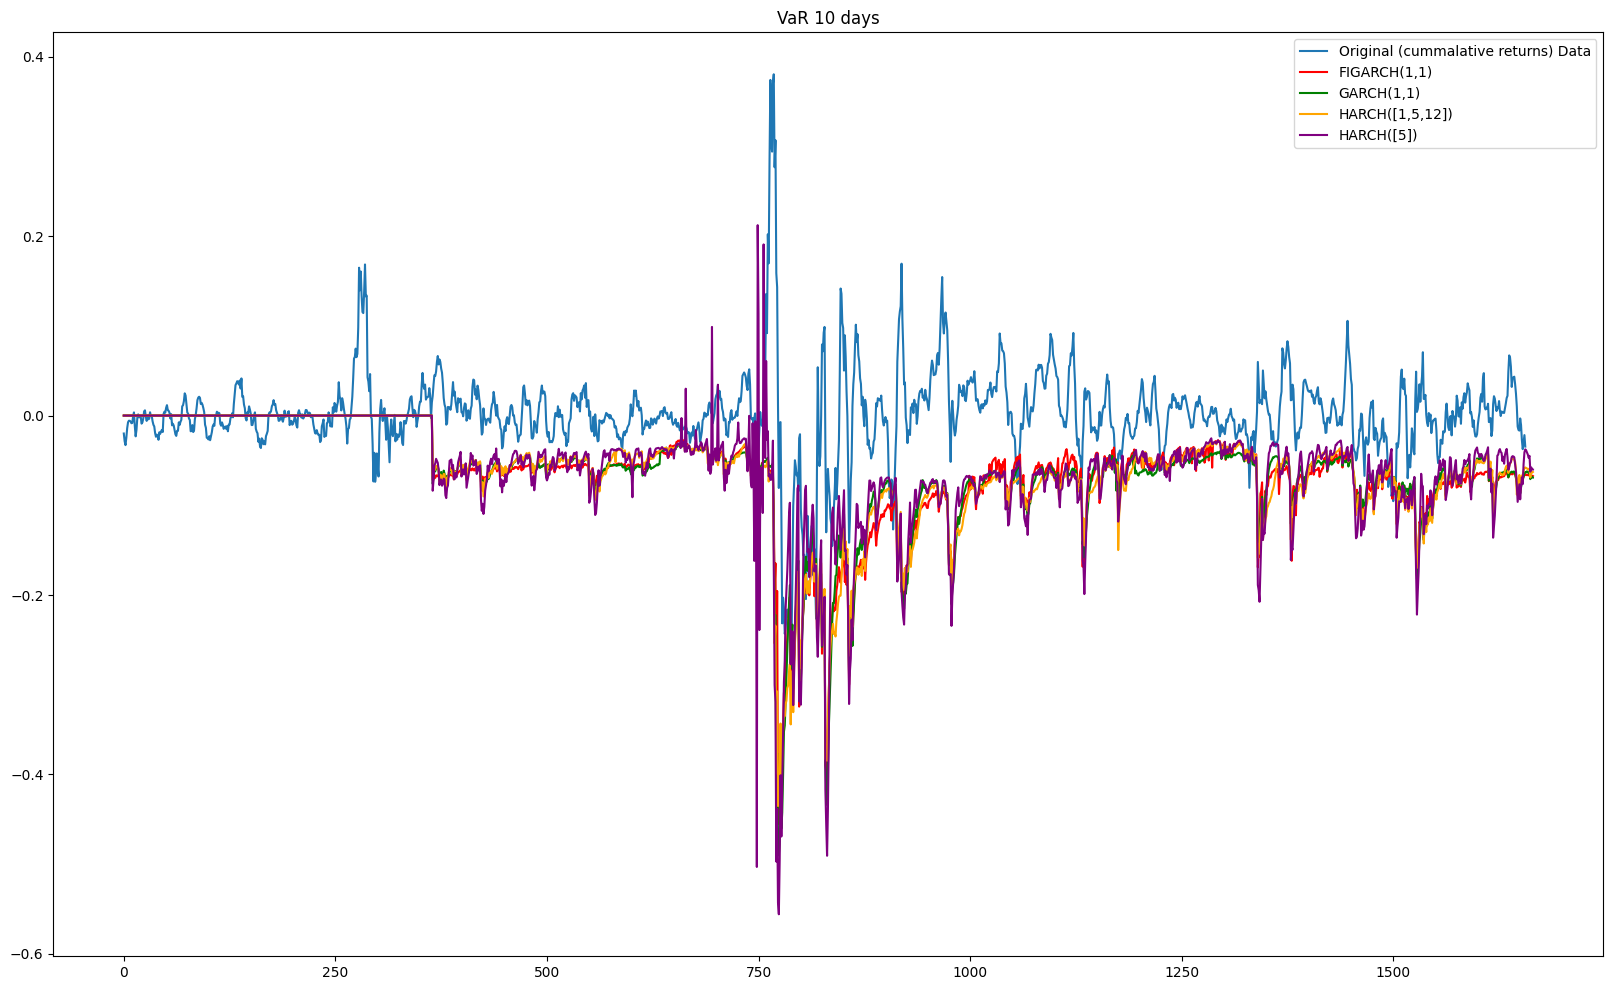

In [78]:
plt.figure(figsize=(20, 12))
plt.plot(cummulative_log_returns, label='Original (cummalative returns) Data')
plt.plot(_figarch_vars, color='red', label='FIGARCH(1,1)')
plt.plot(_norm_vars, color='green', label='GARCH(1,1)')
plt.plot(_harch_1_5_22_vars, color='orange', label='HARCH([1,5,12])')
plt.plot(_harch5_vars, color='purple', label='HARCH([5])')
#optimizes poorly at ~1250
# plt.plot(_aparch_vars, color='orange', label='EGARCH(1,0,1)')
plt.title('VaR 10 days')
plt.legend()
plt.show()

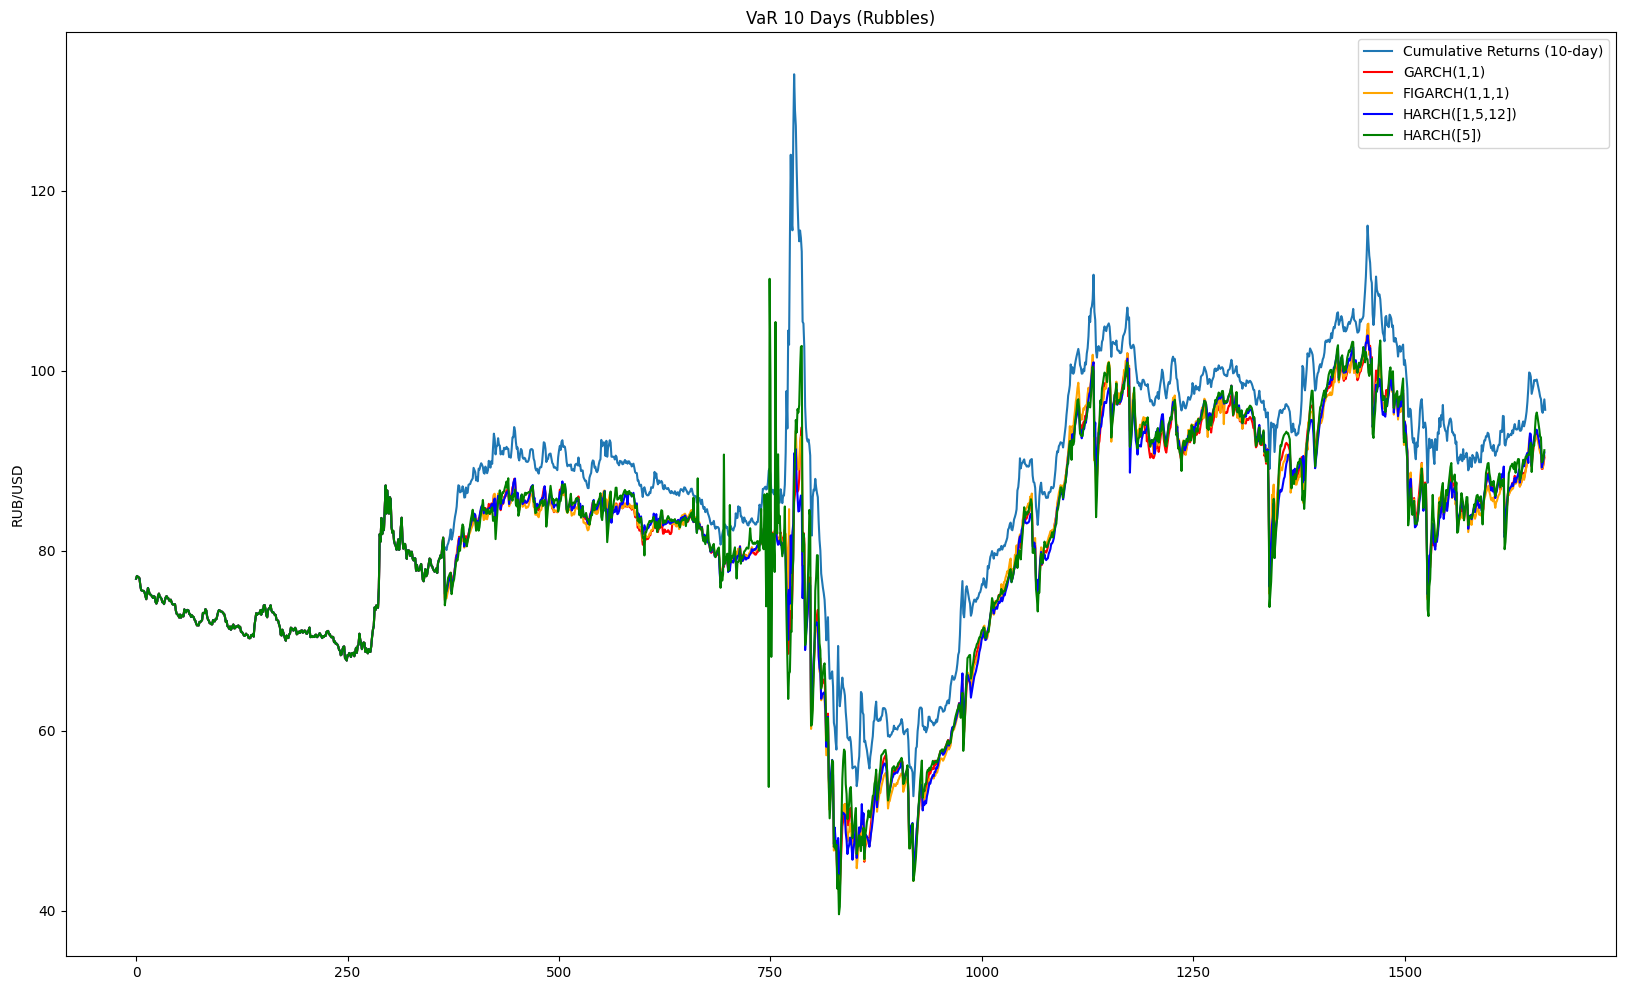

In [74]:
# Plot with regular returns
plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Cumulative Returns (10-day)')
plt.plot(turn_var_into_real_terms(_norm_vars, prices_usd), color='red', label='GARCH(1,1)')
plt.plot(turn_var_into_real_terms(_figarch_vars, prices_usd), color='orange', label='FIGARCH(1,1,1)')
plt.plot(turn_var_into_real_terms(_harch_1_5_22_vars, prices_usd), color='blue', label='HARCH([1,5,12])')
plt.plot(turn_var_into_real_terms(_harch5_vars, prices_usd), color='green', label='HARCH([5])')
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('RUB/USD')
plt.legend()
plt.show()

In [ ]:
import pickle

# assumes _norm_vars already exists
with open("norm_vars.pkl", "wb") as f:
    pickle.dump(_norm_vars, f, protocol=pickle.HIGHEST_PROTOCOL)

In [75]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add GARCH(1,1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_norm_vars, prices_usd),
    mode='lines',
    line=dict(color='red', width=0.5),
    name='GARCH(1, 1)'
))

#Add EGARCH(1, 0, 1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_figarch_vars, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='FIGARCH(1, 0, 1)'
))

# Add Student's t CI (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_harch_1_5_22_vars, prices_usd),
    mode='lines',
    line=dict(color='blue', width=0.5),
    name='HARCH(1, 5, 22)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_harch5_vars, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='HARCH([5]])'
))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


In [117]:
from arch.univariate import ConstantMean, Normal

def MIDASH_type_simulation(m_value, asym_flag):
    def simulate(returns, horizon=10, n_paths=50_000, alpha=0.01):
        vol = MIDASHyperbolic(m=m_value, asym=asym_flag)
        model = ConstantMean(returns)
        model.volatility = vol
        model.distribution = Normal()
        results = model.fit(disp='off')
        h = int(horizon)                          
        forecast = results.forecast(horizon=h, method='simulation')          
        mu = results.params.get("mu", 0)
        sigma2 = forecast.variance.values[0]
        sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
        # nu = results.params.get('nu', 0)
        parameters = SimParams(volatility=sigma, mean=mu)

        sim_returns = solve_local_vol_gbm_log(parameters, 10, n_paths=n_paths)

        VaR = historical_var(sim_returns, alpha)
        
        return VaR

    return simulate

MIDAS_22_asym_simulation = MIDASH_type_simulation(22, True)
MIDAS_22_simulation = MIDASH_type_simulation(22, False)

In [118]:
midas_22_asym_vars = fit_GARCH_VaR(log_returns_usd, MIDAS_22_asym_simulation) 
_midas_22_asym_vars = np.multiply(midas_22_asym_vars, -1)
midas_22_vars = fit_GARCH_VaR(log_returns_usd, MIDAS_22_simulation) 
_midas_22_vars = np.multiply(midas_22_vars, -1)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.508e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 7.505e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


d:\Users\alexa\AppData\Local\Programs\Python\P

In [122]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y= prices_usd,
    mode='lines',
    name='Prices (RUB/USD)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add GARCH(1,1)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_norm_vars, prices_usd),
    mode='lines',
    line=dict(color='red', width=0.5),
    name='GARCH(1, 1)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_figarch_vars, prices_usd),
    mode='lines',
    line=dict(color='orange', width=0.5),
    name='FIGARCH(1, 0, 1)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_midas_22_asym_vars, prices_usd),
    mode='lines',
    line=dict(color='blue', width=0.5),
    name='MIDASHyperbolic(22) assymetric'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_midas_22_vars, prices_usd),
    mode='lines',
    line=dict(color='green', width=0.5),
    name='MIDASHyperbolic(22)'
))

# Add Student's t CI (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_harch_1_5_22_vars, prices_usd),
    mode='lines',
    line=dict(color='purple', width=0.5),
    name='HARCH(1, 5, 22)'
))

fig.add_trace(go.Scatter(
    x=np.arange(len(prices_usd)),
    y=turn_var_into_real_terms(_harch5_vars, prices_usd),
    mode='lines',
    line=dict(color='grey', width=0.5),
    name='HARCH([5]])'
))

# Update layout
fig.update_layout(
    title=f'GARCH VaRs',
    width=1200,
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


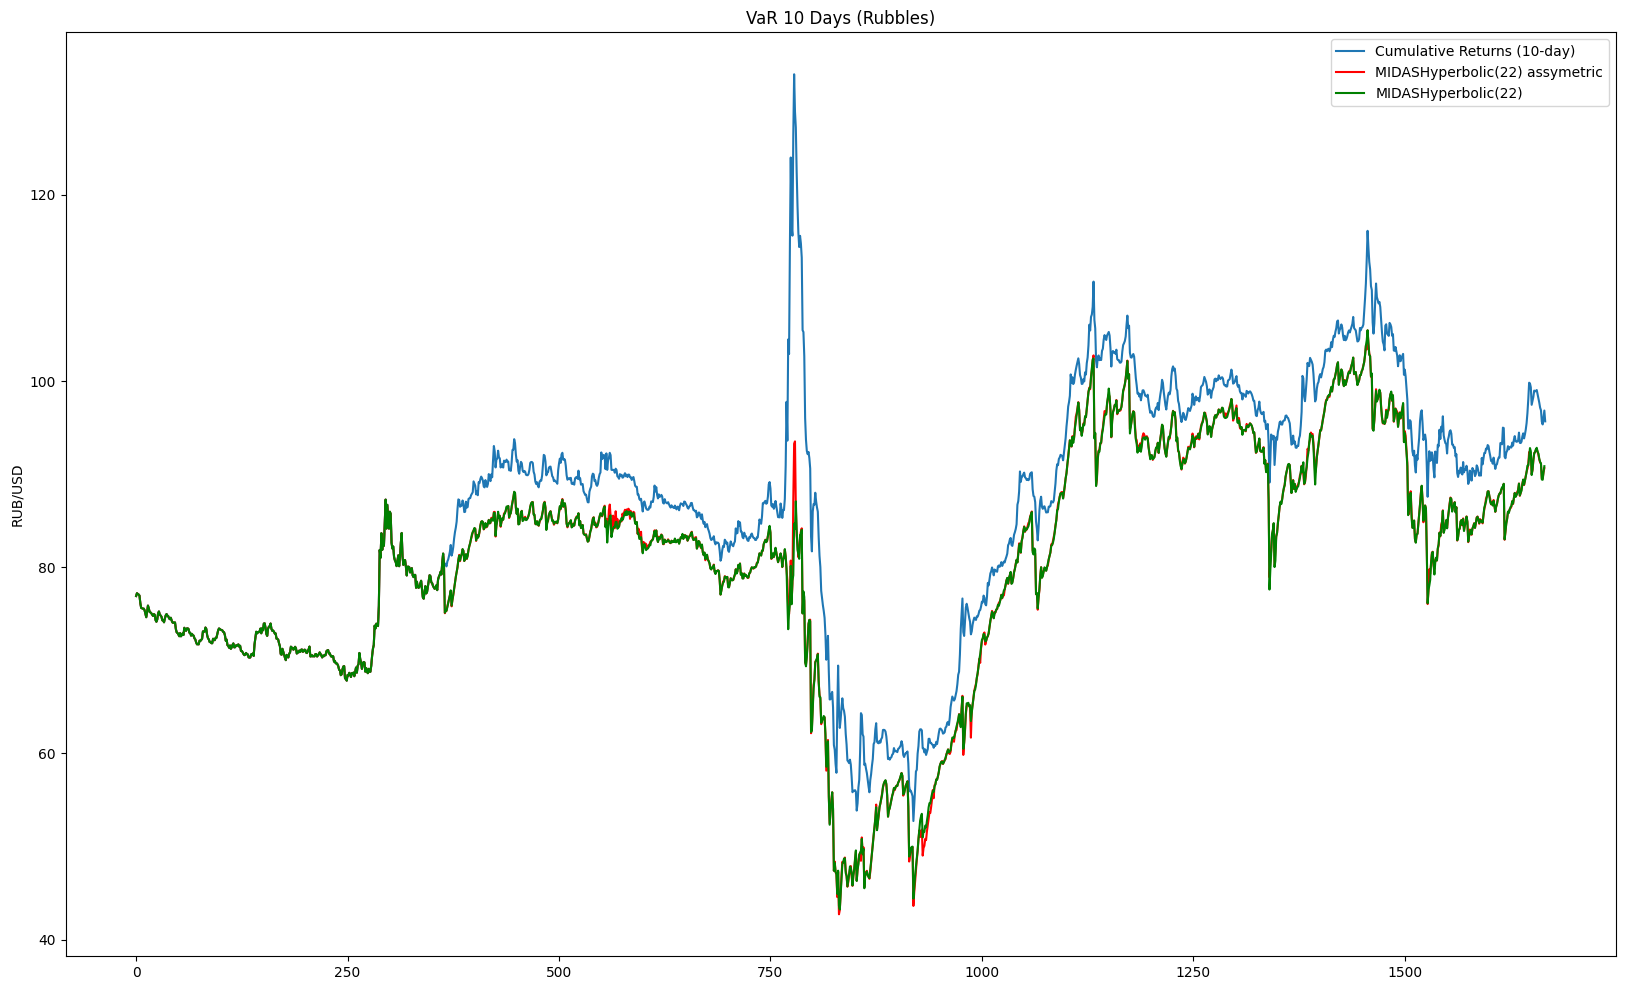

In [121]:
# Plot with regular returns
plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Cumulative Returns (10-day)')
plt.plot(turn_var_into_real_terms(_midas_22_asym_vars, prices_usd), color='red', label='MIDASHyperbolic(22) assymetric')
plt.plot(turn_var_into_real_terms(_midas_22_vars, prices_usd), color='green', label='MIDASHyperbolic(22)')
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('RUB/USD')
plt.legend()
plt.show()

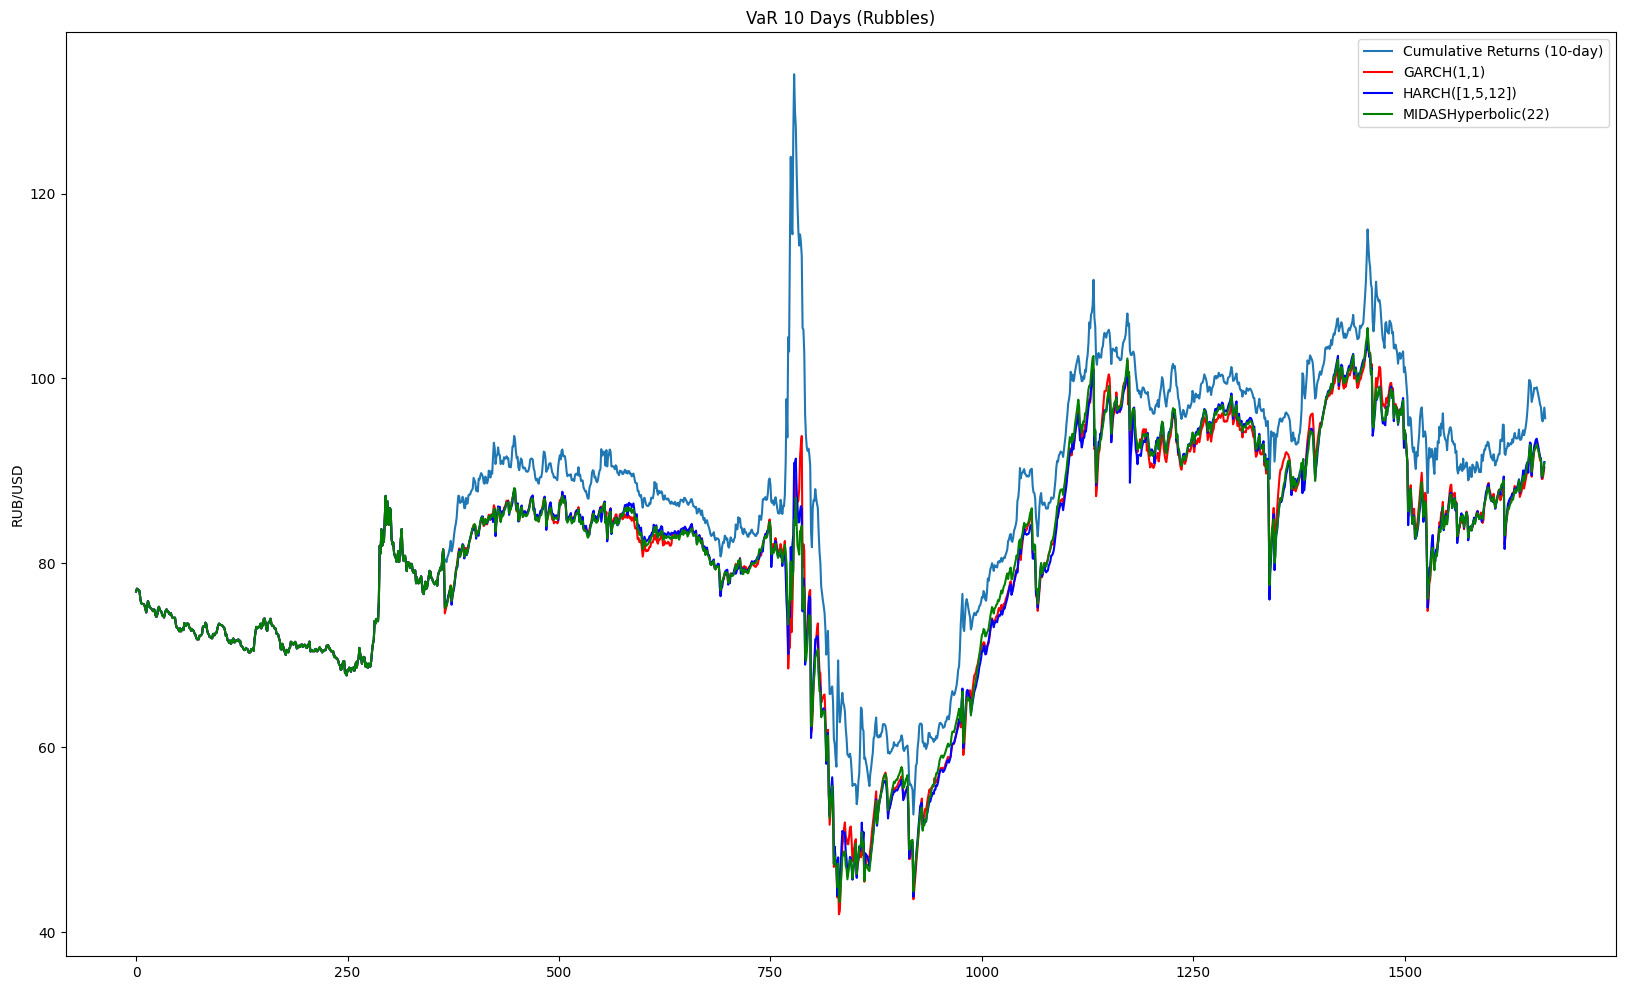

In [123]:
# Plot with regular returns
plt.figure(figsize=(20, 12))
plt.plot(prices_usd, label='Cumulative Returns (10-day)')
plt.plot(turn_var_into_real_terms(_norm_vars, prices_usd), color='red', label='GARCH(1,1)')
plt.plot(turn_var_into_real_terms(_harch_1_5_22_vars, prices_usd), color='blue', label='HARCH([1,5,12])')
plt.plot(turn_var_into_real_terms(_midas_22_vars, prices_usd), color='green', label='MIDASHyperbolic(22)')
plt.title('VaR 10 Days (Rubbles)')
plt.ylabel('RUB/USD')
plt.legend()
plt.show()